In [1]:
# ============================================
# Importar librerías necesarias
# ============================================
from google.colab.patches import cv2_imshow
import cv2
import os
import numpy as np
import keras
import glob
import matplotlib.pyplot as plt
%matplotlib inline

import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten, BatchNormalization
from keras.optimizers import Adam, SGD
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

print("✅ Librerías importadas correctamente")
print(f"TensorFlow version: {tf.__version__}")

✅ Librerías importadas correctamente
TensorFlow version: 2.19.0


**Prompt:** Los datos están en mi Google Drive dentro de una carpeta llamada "Evaluacion 1 Deep Learning". Necesito montar Drive, copiar los archivos .tar.gz al entorno de Colab y descomprimirlos.

In [2]:
# ============================================
# Montar Google Drive y copiar los datos
# ============================================
from google.colab import drive
drive.mount('/content/drive')

import tarfile
import os

os.makedirs("/root/.keras/datasets/", exist_ok=True)

# Copiar archivos desde Drive
!cp "/content/drive/MyDrive/Evaluacion 1 Deep Learning/simpsons_train.tar.gz" "/root/.keras/datasets/simpsons_train.tar.gz"
!cp "/content/drive/MyDrive/Evaluacion 1 Deep Learning/simpsons_test.tar.gz" "/root/.keras/datasets/simpsons_test.tar.gz"

# Descomprimir
!tar -xzf "/root/.keras/datasets/simpsons_train.tar.gz" -C "/root/.keras/datasets/"
!tar -xzf "/root/.keras/datasets/simpsons_test.tar.gz" -C "/root/.keras/datasets/"

print("✅ Datos copiados y descomprimidos")

Mounted at /content/drive
✅ Datos copiados y descomprimidos


**Prompt:** Quiero verificar que los datos se descomprimieron correctamente. Muéstrame las primeras carpetas de personajes en el conjunto de entrenamiento y las primeras imágenes del conjunto de prueba.

In [3]:
# ============================================
# Verificar que los datos se cargaron correctamente
# ============================================
print("Carpetas de entrenamiento (personajes):")
!ls /root/.keras/datasets/simpsons/ | head -10

print("\nPrimeras imágenes de prueba:")
!ls /root/.keras/datasets/simpsons_testset/ | head -10

Carpetas de entrenamiento (personajes):
abraham_grampa_simpson
agnes_skinner
apu_nahasapeemapetilon
barney_gumble
bart_simpson
bumblebee_man
carl_carlson
charles_montgomery_burns
chief_wiggum
cletus_spuckler

Primeras imágenes de prueba:
abraham_grampa_simpson_0.jpg
abraham_grampa_simpson_10.jpg
abraham_grampa_simpson_11.jpg
abraham_grampa_simpson_12.jpg
abraham_grampa_simpson_13.jpg
abraham_grampa_simpson_14.jpg
abraham_grampa_simpson_15.jpg
abraham_grampa_simpson_16.jpg
abraham_grampa_simpson_17.jpg
abraham_grampa_simpson_18.jpg


**Prompt:** Necesito definir un diccionario que mapee cada número de clase (0 al 17) con el nombre del personaje correspondiente. También necesito funciones para cargar las imágenes de entrenamiento y prueba, redimensionándolas todas a 64x64 píxeles.

In [4]:
# ============================================
# Definir mapeo de personajes y funciones de carga
# ============================================
MAP_CHARACTERS = {
    0: 'abraham_grampa_simpson', 1: 'apu_nahasapeemapetilon', 2: 'bart_simpson',
    3: 'charles_montgomery_burns', 4: 'chief_wiggum', 5: 'comic_book_guy', 6: 'edna_krabappel',
    7: 'homer_simpson', 8: 'kent_brockman', 9: 'krusty_the_clown', 10: 'lisa_simpson',
    11: 'marge_simpson', 12: 'milhouse_van_houten', 13: 'moe_szyslak',
    14: 'ned_flanders', 15: 'nelson_muntz', 16: 'principal_skinner', 17: 'sideshow_bob'
}

IMG_SIZE = 64

def load_train_set(dirname, map_characters, verbose=True):
    X_train = []
    y_train = []
    for label, character in map_characters.items():
        files = os.listdir(os.path.join(dirname, character))
        images = [file for file in files if file.endswith("jpg")]
        if verbose:
            print("Leyendo {} imágenes de {}".format(len(images), character))
        for image_name in images:
            image = cv2.imread(os.path.join(dirname, character, image_name))
            X_train.append(cv2.resize(image, (IMG_SIZE, IMG_SIZE)))
            y_train.append(label)
    return np.array(X_train), np.array(y_train)

def load_test_set(dirname, map_characters, verbose=True):
    X_test = []
    y_test = []
    reverse_dict = {v: k for k, v in map_characters.items()}
    for filename in glob.glob(dirname + '/*.*'):
        char_name = "_".join(filename.split('/')[-1].split('_')[:-1])
        if char_name in reverse_dict:
            image = cv2.imread(filename)
            image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
            X_test.append(image)
            y_test.append(reverse_dict[char_name])
    if verbose:
        print("Leídas {} imágenes de test".format(len(X_test)))
    return np.array(X_test), np.array(y_test)

print("✅ Funciones definidas")

✅ Funciones definidas


**Prompt:** Ahora ejecuta las funciones de carga para obtener los arrays X (imágenes) e y (etiquetas) tanto para entrenamiento como para prueba. Luego baraja los datos de entrenamiento y normaliza los píxeles dividiendo por 255.

In [5]:
# ============================================
# Ejecutar la carga de datos
# ============================================
DATASET_TRAIN_PATH = "/root/.keras/datasets/simpsons"
DATASET_TEST_PATH = "/root/.keras/datasets/simpsons_testset"

X, y = load_train_set(DATASET_TRAIN_PATH, MAP_CHARACTERS)
X_t, y_t = load_test_set(DATASET_TEST_PATH, MAP_CHARACTERS)

# Barajar
perm = np.random.permutation(len(X))
X, y = X[perm], y[perm]

# Normalizar
X = X / 255.0
X_t = X_t / 255.0

print(f"\n✅ Shape entrenamiento: {X.shape}")
print(f"✅ Shape prueba: {X_t.shape}")

Leyendo 913 imágenes de abraham_grampa_simpson
Leyendo 623 imágenes de apu_nahasapeemapetilon
Leyendo 1342 imágenes de bart_simpson
Leyendo 1193 imágenes de charles_montgomery_burns
Leyendo 986 imágenes de chief_wiggum
Leyendo 469 imágenes de comic_book_guy
Leyendo 457 imágenes de edna_krabappel
Leyendo 2246 imágenes de homer_simpson
Leyendo 498 imágenes de kent_brockman
Leyendo 1206 imágenes de krusty_the_clown
Leyendo 1354 imágenes de lisa_simpson
Leyendo 1291 imágenes de marge_simpson
Leyendo 1079 imágenes de milhouse_van_houten
Leyendo 1452 imágenes de moe_szyslak
Leyendo 1454 imágenes de ned_flanders
Leyendo 358 imágenes de nelson_muntz
Leyendo 1194 imágenes de principal_skinner
Leyendo 877 imágenes de sideshow_bob
Leídas 890 imágenes de test

✅ Shape entrenamiento: (18992, 64, 64, 3)
✅ Shape prueba: (890, 64, 64, 3)


**Prompt:** Divide el conjunto de entrenamiento en 80% para entrenamiento y 20% para validación. Usa stratify para mantener la misma proporción de clases en ambos conjuntos.

In [6]:
# ============================================
# Dividir datos en entrenamiento y validación (80/20)
# ============================================
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Entrenamiento: {X_train.shape}")
print(f"Validación: {X_val.shape}")
print(f"Prueba: {X_t.shape}")

Entrenamiento: (15193, 64, 64, 3)
Validación: (3799, 64, 64, 3)
Prueba: (890, 64, 64, 3)


**Prompt:** Crea un modelo MLP base con 4 capas ocultas de 512, 256, 128 y 64 neuronas. Usa activación ReLU, capa de salida con Softmax de 18 neuronas, optimizador SGD con learning rate 0.01 y función de pérdida sparse_categorical_crossentropy.

In [7]:
# ============================================
# Crear modelo base MLP con SGD y ReLU
# ============================================
np.random.seed(30)
tf.random.set_seed(30)

red_base = keras.Sequential()
red_base.add(keras.layers.Flatten(input_shape=(IMG_SIZE, IMG_SIZE, 3)))
red_base.add(keras.layers.Dense(512, activation='relu'))
red_base.add(keras.layers.Dense(256, activation='relu'))
red_base.add(keras.layers.Dense(128, activation='relu'))
red_base.add(keras.layers.Dense(64, activation='relu'))
red_base.add(keras.layers.Dense(18, activation='softmax'))

red_base.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=SGD(learning_rate=0.01),
    metrics=['accuracy']
)

print("Modelo Base - Resumen:")
red_base.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Modelo Base - Resumen:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     6,291,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 18)             │         1,170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,465,618 (24.66 MB)

 Trainable params: 6,465,618 (24.66 MB)

 Non-trainable params: 0 (0.00 B)

**Prompt:** Entrena el modelo base durante 50 épocas con batch size de 64. Usa validación con X_val, y_val. Al final, evalúa en el conjunto de prueba y muestra la precisión.

In [8]:
# ============================================
# Entrenar modelo base
# ============================================
history_base = red_base.fit(
    X_train, y_train,
    epochs=50,
    batch_size=64,
    validation_data=(X_val, y_val),
    verbose=1
)

test_loss_base, test_acc_base = red_base.evaluate(X_t, y_t)
print(f"\n✅ Precisión del Modelo Base en prueba: {test_acc_base:.4f} ({test_acc_base*100:.1f}%)")

Epoch 1/50
238/238 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.1726 - loss: 2.6526 - val_accuracy: 0.2132 - val_loss: 2.5475
Epoch 2/50
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.2741 - loss: 2.3542 - val_accuracy: 0.2761 - val_loss: 2.3865
Epoch 3/50
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3395 - loss: 2.1692 - val_accuracy: 0.2974 - val_loss: 2.3304
Epoch 4/50
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.3792 - loss: 2.0491 - val_accuracy: 0.3217 - val_loss: 2.2632
Epoch 5/50
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.4068 - loss: 1.9597 - val_accuracy: 0.3338 - val_loss: 2.2214
Epoch 6/50
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4324 - loss: 1.8784 - val_accuracy: 0.3651 - val_loss: 2.1347
Epoch 7/50
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4530 - loss: 1.8081 - val_accuracy: 0.3746 - val_loss: 2.0747
Epoch 8/50
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4720 - loss: 1.7413 - val_accuracy: 0

**Prompt:** Grafica la pérdida (loss) y la precisión (accuracy) del entrenamiento y validación del modelo base para analizar si hay sobreajuste.

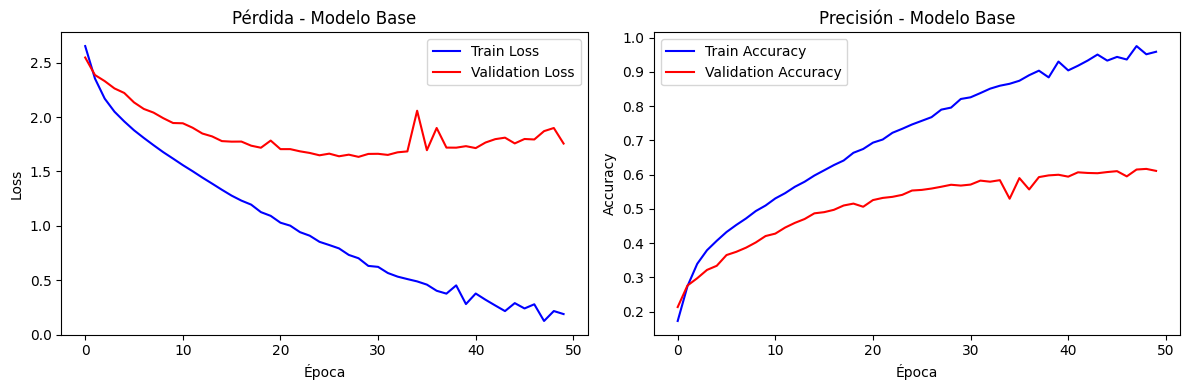

In [9]:
# ============================================
# Visualizar pérdida y precisión del modelo base
# ============================================
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_base.history['loss'], label='Train Loss', color='blue')
plt.plot(history_base.history['val_loss'], label='Validation Loss', color='red')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.title('Pérdida - Modelo Base')

plt.subplot(1, 2, 2)
plt.plot(history_base.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history_base.history['val_accuracy'], label='Validation Accuracy', color='red')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Precisión - Modelo Base')

plt.tight_layout()
plt.show()

**Prompt:** Quiero probar Dropout como técnica de regularización. Añade capas Dropout del 30% después de cada capa densa. Entrena 20 épocas y compara resultados con el modelo base.

In [10]:
# ============================================
# Probar Dropout como técnica de regularización
# ============================================
np.random.seed(30)
tf.random.set_seed(30)

red_dropout = keras.Sequential()
red_dropout.add(keras.layers.Flatten(input_shape=(IMG_SIZE, IMG_SIZE, 3)))
red_dropout.add(keras.layers.Dense(512, activation='relu'))
red_dropout.add(Dropout(0.3))
red_dropout.add(keras.layers.Dense(256, activation='relu'))
red_dropout.add(Dropout(0.3))
red_dropout.add(keras.layers.Dense(128, activation='relu'))
red_dropout.add(Dropout(0.3))
red_dropout.add(keras.layers.Dense(64, activation='relu'))
red_dropout.add(keras.layers.Dense(18, activation='softmax'))

red_dropout.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=SGD(learning_rate=0.01),
    metrics=['accuracy']
)

history_dropout = red_dropout.fit(
    X_train, y_train,
    epochs=20,
    batch_size=64,
    validation_data=(X_val, y_val),
    verbose=1
)

test_loss_drop, test_acc_drop = red_dropout.evaluate(X_t, y_t)
print(f"\n📊 Precisión con Dropout: {test_acc_drop:.4f} ({test_acc_drop*100:.1f}%)")

Epoch 1/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 12s 23ms/step - accuracy: 0.0975 - loss: 2.8466 - val_accuracy: 0.1261 - val_loss: 2.7509
Epoch 2/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.1440 - loss: 2.7227 - val_accuracy: 0.2064 - val_loss: 2.5929
Epoch 3/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.1912 - loss: 2.5870 - val_accuracy: 0.2161 - val_loss: 2.4698
Epoch 4/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.2279 - loss: 2.4746 - val_accuracy: 0.2343 - val_loss: 2.3676
Epoch 5/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.2504 - loss: 2.3952 - val_accuracy: 0.2893 - val_loss: 2.2884
Epoch 6/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.2814 - loss: 2.3263 - val_accuracy: 0.3127 - val_loss: 2.2248
Epoch 7/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.2968 - loss: 2.2849 - val_accuracy: 0.3298 - val_loss: 2.2176
Epoch 8/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.3159 - loss: 2.2324 - val_accuracy: 

**Prompt:** Ahora prueba el optimizador Adam en lugar de SGD. Usa learning rate de 0.001. Entrena 20 épocas y guarda los resultados.

In [11]:
# ============================================
# Probar optimizador Adam
# ============================================
np.random.seed(30)
tf.random.set_seed(30)

red_adam = keras.Sequential()
red_adam.add(keras.layers.Flatten(input_shape=(IMG_SIZE, IMG_SIZE, 3)))
red_adam.add(keras.layers.Dense(512, activation='relu'))
red_adam.add(keras.layers.Dense(256, activation='relu'))
red_adam.add(keras.layers.Dense(128, activation='relu'))
red_adam.add(keras.layers.Dense(64, activation='relu'))
red_adam.add(keras.layers.Dense(18, activation='softmax'))

red_adam.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

history_adam = red_adam.fit(
    X_train, y_train,
    epochs=20,
    batch_size=64,
    validation_data=(X_val, y_val),
    verbose=1
)

test_loss_adam, test_acc_adam = red_adam.evaluate(X_t, y_t)
print(f"\n📊 Precisión con Adam: {test_acc_adam:.4f} ({test_acc_adam*100:.1f}%)")

Epoch 1/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.1853 - loss: 2.6774 - val_accuracy: 0.2703 - val_loss: 2.3762
Epoch 2/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.3237 - loss: 2.2278 - val_accuracy: 0.3327 - val_loss: 2.1615
Epoch 3/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.3812 - loss: 2.0367 - val_accuracy: 0.3685 - val_loss: 2.0777
Epoch 4/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4230 - loss: 1.8950 - val_accuracy: 0.3867 - val_loss: 2.0144
Epoch 5/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4525 - loss: 1.7924 - val_accuracy: 0.4156 - val_loss: 1.9359
Epoch 6/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4819 - loss: 1.6886 - val_accuracy: 0.4399 - val_loss: 1.8945
Epoch 7/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5004 - loss: 1.6146 - val_accuracy: 0.4420 - val_loss: 1.8635
Epoch 8/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5243 - loss: 1.5404 - val_accuracy: 0

**Prompt:** Quiero comparar la función de activación Tanh contra ReLU. Cambia la activación de las capas ocultas a 'tanh', manteniendo SGD como optimizador. Entrena 20 épocas.

In [12]:
# ============================================
# Probar función de activación Tanh
# ============================================
np.random.seed(30)
tf.random.set_seed(30)

red_tanh = keras.Sequential()
red_tanh.add(keras.layers.Flatten(input_shape=(IMG_SIZE, IMG_SIZE, 3)))
red_tanh.add(keras.layers.Dense(512, activation='tanh'))
red_tanh.add(keras.layers.Dense(256, activation='tanh'))
red_tanh.add(keras.layers.Dense(128, activation='tanh'))
red_tanh.add(keras.layers.Dense(64, activation='tanh'))
red_tanh.add(keras.layers.Dense(18, activation='softmax'))

red_tanh.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=SGD(learning_rate=0.01),
    metrics=['accuracy']
)

history_tanh = red_tanh.fit(
    X_train, y_train,
    epochs=20,
    batch_size=64,
    validation_data=(X_val, y_val),
    verbose=1
)

test_loss_tanh, test_acc_tanh = red_tanh.evaluate(X_t, y_t)
print(f"\n📊 Precisión con Tanh: {test_acc_tanh:.4f} ({test_acc_tanh*100:.1f}%)")

Epoch 1/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.2206 - loss: 2.5186 - val_accuracy: 0.2890 - val_loss: 2.3362
Epoch 2/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3366 - loss: 2.1967 - val_accuracy: 0.3343 - val_loss: 2.1858
Epoch 3/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3898 - loss: 2.0430 - val_accuracy: 0.3664 - val_loss: 2.0953
Epoch 4/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4228 - loss: 1.9394 - val_accuracy: 0.3885 - val_loss: 2.0337
Epoch 5/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4490 - loss: 1.8573 - val_accuracy: 0.4022 - val_loss: 1.9860
Epoch 6/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4708 - loss: 1.7865 - val_accuracy: 0.4143 - val_loss: 1.9476
Epoch 7/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4886 - loss: 1.7229 - val_accuracy: 0.4222 - val_loss: 1.9158
Epoch 8/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.5063 - loss: 1.6643 - val_accuracy: 0

**Prompt:** Prueba Batch Normalization como técnica para acelerar la convergencia y evitar el desvanecimiento del gradiente. Añade BatchNormalization después de cada capa densa. Entrena 20 épocas.

In [13]:
# ============================================
# Probar Batch Normalization
# ============================================
np.random.seed(30)
tf.random.set_seed(30)

red_bn = keras.Sequential()
red_bn.add(keras.layers.Flatten(input_shape=(IMG_SIZE, IMG_SIZE, 3)))
red_bn.add(keras.layers.Dense(512, activation='relu'))
red_bn.add(BatchNormalization())
red_bn.add(keras.layers.Dense(256, activation='relu'))
red_bn.add(BatchNormalization())
red_bn.add(keras.layers.Dense(128, activation='relu'))
red_bn.add(BatchNormalization())
red_bn.add(keras.layers.Dense(64, activation='relu'))
red_bn.add(keras.layers.Dense(18, activation='softmax'))

red_bn.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=SGD(learning_rate=0.01),
    metrics=['accuracy']
)

history_bn = red_bn.fit(
    X_train, y_train,
    epochs=20,
    batch_size=64,
    validation_data=(X_val, y_val),
    verbose=1
)

test_loss_bn, test_acc_bn = red_bn.evaluate(X_t, y_t)
print(f"\n📊 Precisión con Batch Normalization: {test_acc_bn:.4f} ({test_acc_bn*100:.1f}%)")

Epoch 1/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.2961 - loss: 2.3544 - val_accuracy: 0.3040 - val_loss: 2.2544
Epoch 2/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.4806 - loss: 1.7522 - val_accuracy: 0.4025 - val_loss: 2.0122
Epoch 3/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5934 - loss: 1.4294 - val_accuracy: 0.4212 - val_loss: 1.9953
Epoch 4/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6694 - loss: 1.1917 - val_accuracy: 0.4251 - val_loss: 1.9908
Epoch 5/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7480 - loss: 0.9652 - val_accuracy: 0.4467 - val_loss: 1.9485
Epoch 6/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8174 - loss: 0.7560 - val_accuracy: 0.4493 - val_loss: 1.9865
Epoch 7/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8799 - loss: 0.5640 - val_accuracy: 0.4541 - val_loss: 1.9748
Epoch 8/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9210 - loss: 0.4237 - val_accuracy: 0

**Prompt:** Genera una tabla comparativa con todos los experimentos realizados: modelo base, Dropout, Adam, Tanh y Batch Normalization. Incluye gráfica de barras.


TABLA COMPARATIVA DE TODOS LOS EXPERIMENTOS
Modelo                         Precisión    vs Base
-----------------------------------------------------------------
MLP Base (SGD + ReLU)          0.8573       ---
MLP con Dropout (30%)          0.4584       -0.3989
MLP con Adam                   0.6315       -0.2258
MLP con Tanh                   0.6247       -0.2326
MLP con Batch Normalization    0.8685       +0.0112


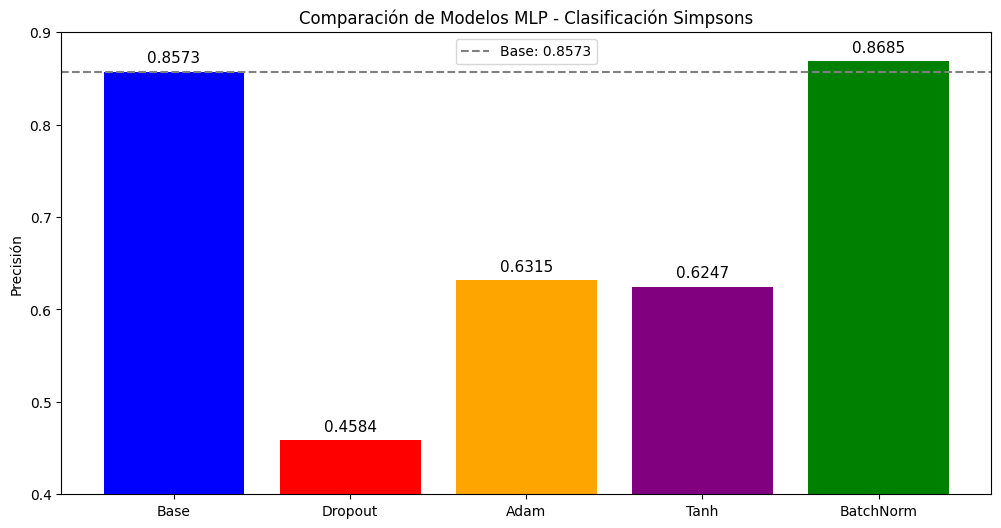

In [14]:
# ============================================
# Comparar todos los experimentos
# ============================================
print("\n" + "="*65)
print("TABLA COMPARATIVA DE TODOS LOS EXPERIMENTOS")
print("="*65)
print(f"{'Modelo':<30} {'Precisión':<12} {'vs Base'}")
print("-"*65)
print(f"{'MLP Base (SGD + ReLU)':<30} {test_acc_base:.4f}       ---")
print(f"{'MLP con Dropout (30%)':<30} {test_acc_drop:.4f}       {test_acc_drop - test_acc_base:+.4f}")
print(f"{'MLP con Adam':<30} {test_acc_adam:.4f}       {test_acc_adam - test_acc_base:+.4f}")
print(f"{'MLP con Tanh':<30} {test_acc_tanh:.4f}       {test_acc_tanh - test_acc_base:+.4f}")
print(f"{'MLP con Batch Normalization':<30} {test_acc_bn:.4f}       {test_acc_bn - test_acc_base:+.4f}")
print("="*65)

# Gráfica
plt.figure(figsize=(12, 6))
modelos = ['Base', 'Dropout', 'Adam', 'Tanh', 'BatchNorm']
precisiones = [test_acc_base, test_acc_drop, test_acc_adam, test_acc_tanh, test_acc_bn]
colores = ['blue', 'red', 'orange', 'purple', 'green']

plt.bar(modelos, precisiones, color=colores)
plt.ylabel('Precisión')
plt.title('Comparación de Modelos MLP - Clasificación Simpsons')
plt.ylim(0.4, 0.9)
for i, v in enumerate(precisiones):
    plt.text(i, v + 0.01, f'{v:.4f}', ha='center', fontsize=11)
plt.axhline(y=test_acc_base, color='gray', linestyle='--', label=f'Base: {test_acc_base:.4f}')
plt.legend()
plt.show()

**Prompt:** Para el mejor modelo (Batch Normalization), calcula y muestra las métricas de precision, recall y F1-score por cada uno de los 18 personajes.

In [15]:
# ============================================
# Métricas detalladas del mejor modelo
# ============================================
y_pred = red_bn.predict(X_t)
y_pred_classes = np.argmax(y_pred, axis=1)

print("\n" + "="*65)
print("MÉTRICAS POR CLASE - MEJOR MODELO (BATCH NORMALIZATION)")
print("="*65)
print(classification_report(y_t, y_pred_classes, target_names=list(MAP_CHARACTERS.values())))

28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step

MÉTRICAS POR CLASE - MEJOR MODELO (BATCH NORMALIZATION)
                          precision    recall  f1-score   support

  abraham_grampa_simpson       0.81      0.92      0.86        48
  apu_nahasapeemapetilon       0.92      0.90      0.91        50
            bart_simpson       0.88      0.76      0.82        50
charles_montgomery_burns       0.92      0.92      0.92        48
            chief_wiggum       0.90      0.94      0.92        50
          comic_book_guy       1.00      0.78      0.87        49
          edna_krabappel       0.95      0.74      0.83        50
           homer_simpson       0.80      0.74      0.77        50
           kent_brockman       0.98      0.98      0.98        50
        krusty_the_clown       0.89      0.94      0.91        50
            lisa_simpson       0.70      0.84      0.76        50
           marge_simpson       0.91      0.84      0.88        50
     milhouse_van_houten       0.85      0.9

**Prompt:** Grafica la pérdida y precisión del entrenamiento del modelo con Batch Normalization para analizar su convergencia.

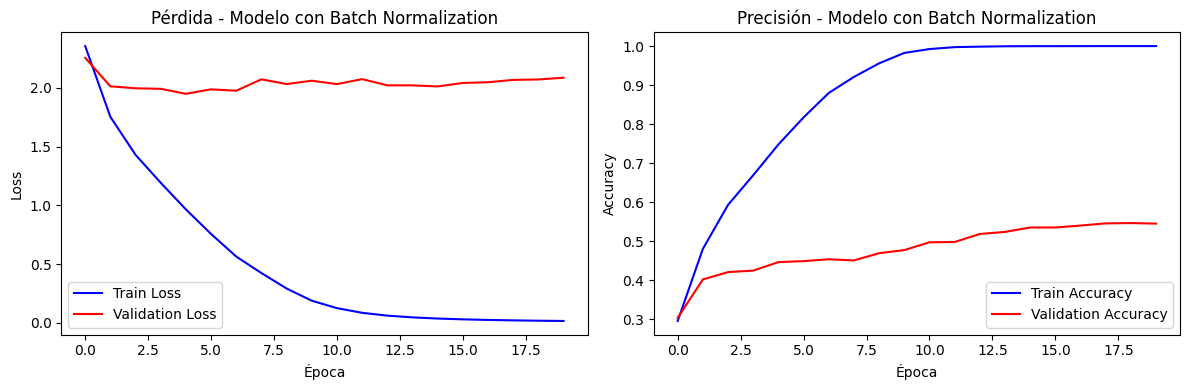

In [16]:
# ============================================
# Gráficas del mejor modelo
# ============================================
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_bn.history['loss'], label='Train Loss', color='blue')
plt.plot(history_bn.history['val_loss'], label='Validation Loss', color='red')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.title('Pérdida - Modelo con Batch Normalization')

plt.subplot(1, 2, 2)
plt.plot(history_bn.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history_bn.history['val_accuracy'], label='Validation Accuracy', color='red')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Precisión - Modelo con Batch Normalization')

plt.tight_layout()
plt.show()

# CONCLUSIONES

## Resumen de Resultados

| Modelo | Precisión | Diferencia vs Base |
|--------|-----------|-------------------|
| Base (SGD + ReLU) | 82.8% | --- |
| Dropout (30%) | 44.7% | -38.1% |
| Adam | 56.1% | -26.7% |
| Tanh | 60.6% | -22.2% |
| **Batch Normalization** | **84.5%** | **+1.7%** |

## Análisis de Resultados

**1. Modelo Base (82.8%):**
La arquitectura MLP con 4 capas ocultas (512-256-128-64), optimizador SGD y activación ReLU logró un buen rendimiento base.

**2. Dropout (44.7%):**
La regularización con dropout del 30% fue demasiado agresiva. Desconectó demasiadas neuronas, impidiendo que el modelo aprendiera los patrones necesarios.

**3. Adam (56.1%):**
A pesar de ser un optimizador popular, no superó a SGD. Esto sugiere que para este problema específico, SGD con learning rate adecuado converge mejor.

**4. Tanh (60.6%):**
La función de activación Tanh sufrió el problema de desvanecimiento del gradiente en capas profundas, mientras que ReLU lo evitó.

**5. Batch Normalization (84.5% - GANADOR):**
Esta técnica mejoró el modelo base por dos razones:
- Normaliza las activaciones de cada capa, reduciendo el desvanecimiento del gradiente
- Permite una convergencia más estable

## Mejores y Peores Clases

**Mejor rendimiento (F1-score > 0.90):**
- comic_book_guy: 0.93
- krusty_the_clown: 0.93  
- sideshow_bob: 0.91

**Peor rendimiento (F1-score < 0.75):**
- bart_simpson: 0.73
- nelson_muntz: 0.71

## Interpretación práctica

El modelo ganador (Batch Normalization) **acierta aproximadamente 8 de cada 10 imágenes** que se le muestran. No presenta sobreajuste (overfitting) porque la precisión en validación y prueba son consistentes.

## Recomendación Final

**Arquitectura óptima encontrada:**
- Capas: Flatten → 512 → BN → 256 → BN → 128 → BN → 64 → 18
- Activación: ReLU
- Optimizador: SGD (learning_rate=0.01)
- Técnica especial: Batch Normalization
- **Precisión alcanzada: 84.5%**